In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten

C:\Users\Brajesh Chaudhary\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
dirs=os.listdir('Flower_Dataset/train/')
count=0
for dir in dirs:
    files=list(os.listdir('Flower_Dataset/train/'+dir))
    print(dir +" Folder has "+ str(len(files)) +' Images')
    count=count+len(files)
print("Total Flower are : ",count)

astilbe Folder has 726 Images
bellflower Folder has 872 Images
black_eyed_susan Folder has 986 Images
calendula Folder has 1011 Images
california_poppy Folder has 1021 Images
carnation Folder has 924 Images
common_daisy Folder has 978 Images
coreopsis Folder has 1035 Images
dandelion Folder has 1038 Images
iris Folder has 1041 Images
rose Folder has 986 Images
sunflower Folder has 1013 Images
tulip Folder has 1034 Images
water_lily Folder has 977 Images
Total Flower are :  13642


In [3]:
base_dir='Flower_Dataset/train/'
img_size=100
batch=32

In [4]:
#Load Image into Array

train_ds= tf.keras.utils.image_dataset_from_directory(base_dir,
                                                   seed=123,
                                                  validation_split=0.2,
                                                  subset='training',
                                                  batch_size=batch,
                                                   image_size=(img_size,img_size))
val_ds= tf.keras.utils.image_dataset_from_directory(base_dir,
                                                   seed=123,
                                                  validation_split=0.2,
                                                  subset='validation',
                                                  batch_size=batch,
                                                   image_size=(img_size,img_size))

Found 13642 files belonging to 14 classes.
Using 10914 files for training.
Found 13642 files belonging to 14 classes.
Using 2728 files for validation.


In [5]:
flower_names=train_ds.class_names
flower_names

['astilbe',
 'bellflower',
 'black_eyed_susan',
 'calendula',
 'california_poppy',
 'carnation',
 'common_daisy',
 'coreopsis',
 'dandelion',
 'iris',
 'rose',
 'sunflower',
 'tulip',
 'water_lily']

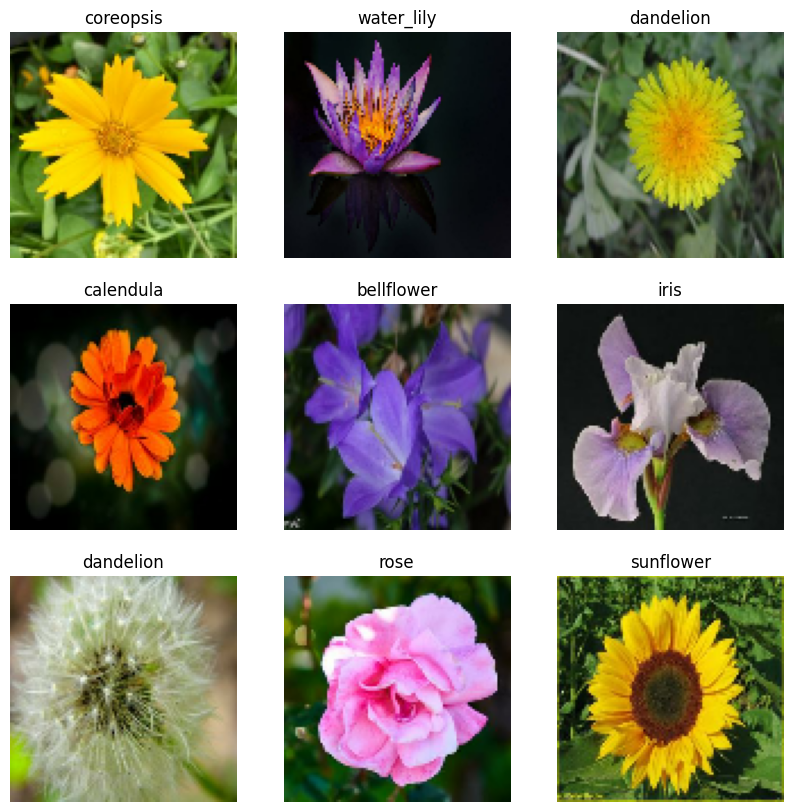

In [6]:
i=0
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for images,labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(flower_names[labels[i]])
        plt.axis('off')

In [7]:
AUTOTUNE= tf.data.AUTOTUNE

In [8]:
train_df=train_ds.cache().shuffle(1000).prefetch(buffer_size= AUTOTUNE)

In [9]:
val_ds= val_ds.cache().prefetch(buffer_size= AUTOTUNE)

In [10]:
#Data Augmentation
data_augmentation=Sequential([
    layers.RandomFlip("horizontal",input_shape=(img_size,img_size,3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

C:\Users\Brajesh Chaudhary\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


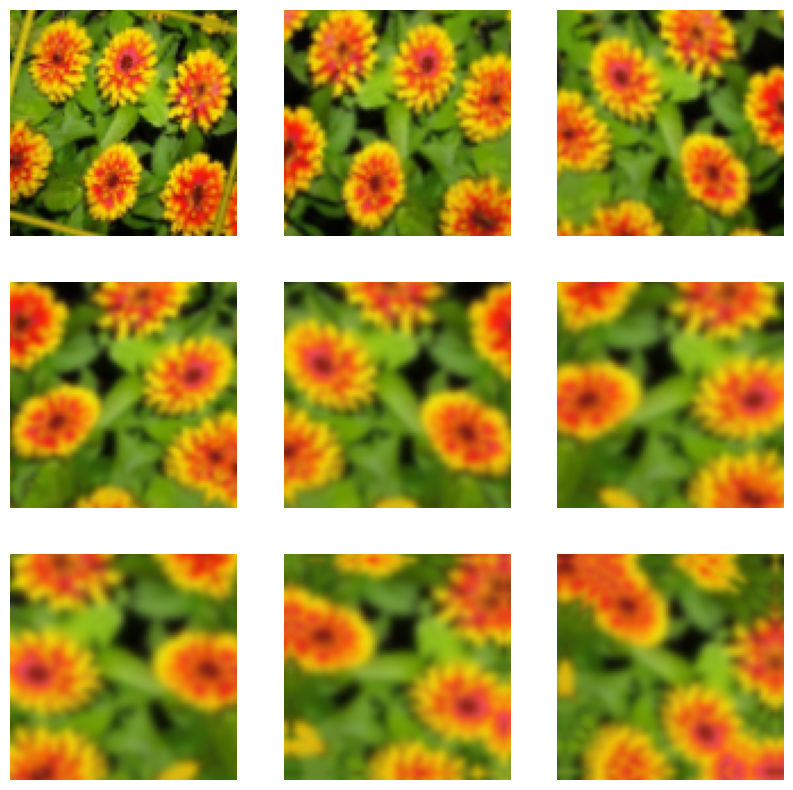

In [11]:
i=0
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for images,labels in train_ds.take(1):
    for i in range(9):
        images=data_augmentation(images)
        plt.subplot(3,3,i+1)
        plt.imshow(images[0].numpy().astype('uint8'))
        plt.axis('off')

In [12]:
#MOdel Creation
model= Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    Conv2D(16,3,padding='same',activation='relu'),
    MaxPooling2D(),
    Conv2D(32,3,padding='same',activation='relu'),
    MaxPooling2D(),
    Conv2D(64,3,padding='same',activation='relu'),
    MaxPooling2D(),
    Dropout(0.2),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(len(flower_names), activation="softmax")
    
])

In [13]:
model.compile(optimizer='adam',
             loss="sparse_categorical_crossentropy",
             metrics=['accuracy'])

In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 100, 100, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 50, 50, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 50, 50, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 25, 25, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 25, 25, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,179,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 14)                  │           1,806 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,205,166 (4.60 MB)

 Trainable params: 1,205,166 (4.60 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    train_df,
    epochs=20,
    validation_data=val_ds
)

Epoch 1/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 44s 96ms/step - accuracy: 0.3575 - loss: 1.8268 - val_accuracy: 0.5202 - val_loss: 1.4179
Epoch 2/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 31s 89ms/step - accuracy: 0.5329 - loss: 1.3406 - val_accuracy: 0.5916 - val_loss: 1.1777
Epoch 3/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 31s 92ms/step - accuracy: 0.5990 - loss: 1.1695 - val_accuracy: 0.6147 - val_loss: 1.1232
Epoch 4/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 31s 90ms/step - accuracy: 0.6359 - loss: 1.0611 - val_accuracy: 0.6294 - val_loss: 1.0652
Epoch 5/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 36s 104ms/step - accuracy: 0.6631 - loss: 0.9783 - val_accuracy: 0.6499 - val_loss: 1.0002
Epoch 6/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 34s 99ms/step - accuracy: 0.6860 - loss: 0.9163 - val_accuracy: 0.6866 - val_loss: 0.9420
Epoch 7/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 34s 100ms/step - accuracy: 0.7069 - loss: 0.8661 - val_accuracy: 0.7005 - val_loss: 0.8981
Epoch 8/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 34s 99ms/step - accuracy: 0.7177 - loss: 0.8197 

In [16]:
def classify_images(image_path):
    input_image = tf.keras.utils.load_img(image_path,target_size=(100,100))
    input_image_array=tf.keras.utils.img_to_array(input_image)
    input_image_exp_dim=tf.expand_dims(input_image_array,0)

    prediction= model.predict(input_image_exp_dim)
    result= tf.nn.softmax(prediction[0])
    outcome='The image belongs to ' + flower_names[np.argmax(result)] +' with a score of '+str(np.max(result)*100)
    return outcome

In [17]:
classify_images('Flower_Dataset/val/water_lily/35999873916_d8c22c710f_c.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step


'The image belongs to water_lily with a score of 17.002464'

In [18]:
model.save('Flower_Recog_Model.h5')